# Задание 1. Семантическая сегментация облаков точек

**Проект:** Интеллектуальная сегментация деталей трубопроводной арматуры по данным LiDAR.

**Датасет:** 500 размеченных облаков точек в формате ASCII `.ply` (`x y z scalar_Label`).

**Цель:** обучить и сравнить 3 архитектуры — **PointNet**, **PointNet++**, **DGCNN** — на задаче поточечной классификации.

**Метрики:** Overall Accuracy, mIoU, per-class IoU, F1-score, Confusion Matrix.

**Разбиение:** 70/15/15 по файлам (объектам), а не по точкам.



## 1. Импорты и конфигурация

In [ ]:
import os, glob, random, time, json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, jaccard_score, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

DATA_DIR = Path(r'C:\Users\jorjanoo\Downloads\5')

N_POINTS    = 2048
BATCH_SIZE  = 8
EPOCHS      = 15
LR          = 1e-3
WEIGHT_DECAY = 1e-4

RESULTS_DIR = Path('results_task1'); RESULTS_DIR.mkdir(exist_ok=True)
print('Files in dataset:', len(list(DATA_DIR.glob('*.ply'))) if DATA_DIR.exists() else 'NOT FOUND')

Device: cpu
Files in dataset: 500


## 2. Чтение `.ply` и быстрый EDA

In [3]:
def read_ply_ascii(path):
    """Парсит ASCII PLY вида: x y z scalar_Label."""
    with open(path, 'r') as f:
        while True:
            line = f.readline()
            if not line:
                break
            if line.strip() == 'end_header':
                break
        data = np.loadtxt(f)
    pts    = data[:, :3].astype(np.float32)
    labels = data[:, 3].astype(np.int64)
    return pts, labels

all_files = sorted(DATA_DIR.glob('*.ply'))
print(f'Найдено файлов: {len(all_files)}')
pts0, lab0 = read_ply_ascii(all_files[0])
print('Пример:', all_files[0].name, '— точек:', len(pts0), 'классов в файле:', sorted(set(lab0.tolist())))

Найдено файлов: 500
Пример: valve_0001_lidar_classes.ply — точек: 13112 классов в файле: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


EDA: 100%|██████████| 500/500 [00:03<00:00, 133.10it/s]


Точек на облако: min=11382, max=13527, mean=12384
Классов: 14 -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Распределение классов:
  класс  0:      9451 ( 0.15%)
  класс  1:       969 ( 0.02%)
  класс  2:    292874 ( 4.73%)
  класс  3:     35100 ( 0.57%)
  класс  4:      2376 ( 0.04%)
  класс  5:    807029 (13.03%)
  класс  6:    179641 ( 2.90%)
  класс  7:     42995 ( 0.69%)
  класс  8:    839548 (13.56%)
  класс  9:    869174 (14.04%)
  класс 10:   1734742 (28.02%)
  класс 11:    367949 ( 5.94%)
  класс 12:    665370 (10.75%)
  класс 13:    344840 ( 5.57%)


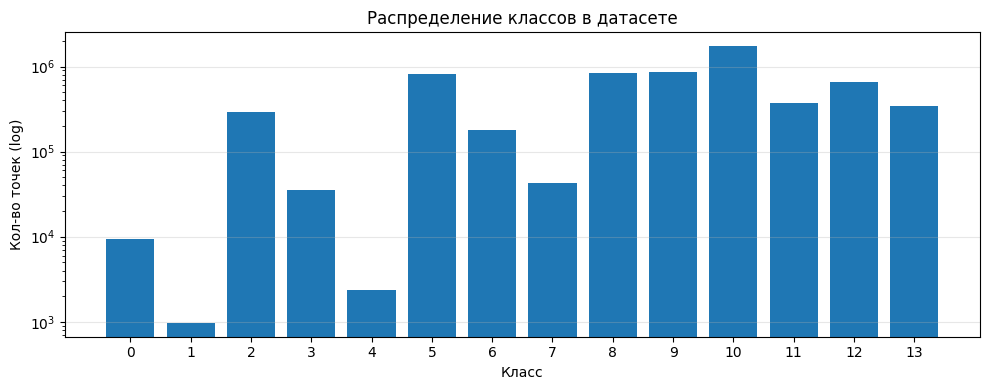

In [4]:
# Считаем глобальное число классов и распределение точек по классам
size_list = []
label_counter = Counter()
for p in tqdm(all_files, desc='EDA'):
    pts, lab = read_ply_ascii(p)
    size_list.append(len(pts))
    label_counter.update(lab.tolist())

classes_sorted = sorted(label_counter.keys())
NUM_CLASSES = int(max(classes_sorted)) + 1
total = sum(label_counter.values())
print(f'Точек на облако: min={min(size_list)}, max={max(size_list)}, mean={int(np.mean(size_list))}')
print(f'Классов: {NUM_CLASSES} -> {classes_sorted}')
print('Распределение классов:')
for c in range(NUM_CLASSES):
    cnt = label_counter.get(c, 0)
    print(f'  класс {c:2d}: {cnt:>9d} ({100*cnt/total:5.2f}%)')

counts = np.array([label_counter.get(c, 0) for c in range(NUM_CLASSES)], dtype=np.float64)
plt.figure(figsize=(10, 4))
plt.bar(range(NUM_CLASSES), counts)
plt.yscale('log'); plt.xlabel('Класс'); plt.ylabel('Кол-во точек (log)')
plt.title('Распределение классов в датасете')
plt.xticks(range(NUM_CLASSES)); plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=120); plt.show()

## 3. Препроцессинг и Dataset

In [5]:
def normalize_points(pts):
    """Центрирование + масштабирование в единичный шар."""
    pts = pts - pts.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(pts, axis=1).max()
    if scale > 0:
        pts = pts / scale
    return pts.astype(np.float32)

def augment_points(pts):
    """Аугментация: поворот вокруг Z + малый гауссовский шум + случайный масштаб."""
    theta = np.random.uniform(0, 2 * np.pi)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
    pts = pts @ R.T
    pts = pts + np.random.normal(scale=0.01, size=pts.shape).astype(np.float32)
    pts = pts * np.float32(np.random.uniform(0.9, 1.1))
    return pts

class LidarSegDataset(Dataset):
    """Возвращает фиксированное число точек на облако (sample/pad).
    Координаты центрируются и масштабируются. Метки приходят как есть."""
    def __init__(self, files, n_points=N_POINTS, training=True):
        self.files = list(files)
        self.n_points = n_points
        self.training = training

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        pts, lab = read_ply_ascii(self.files[idx])
        pts = normalize_points(pts)
        # сэмплим N точек
        N = len(pts)
        if N >= self.n_points:
            choice = np.random.choice(N, self.n_points, replace=False)
        else:
            choice = np.random.choice(N, self.n_points, replace=True)
        pts = pts[choice]; lab = lab[choice]
        if self.training:
            pts = augment_points(pts)
        return torch.from_numpy(pts), torch.from_numpy(lab)

## 4. Разбиение train / val / test = 70 / 15 / 15 по файлам

In [6]:
rng = np.random.default_rng(SEED)
files_arr = np.array(all_files)
perm = rng.permutation(len(files_arr))
files_arr = files_arr[perm]

n = len(files_arr)
n_train = int(round(0.70 * n))
n_val   = int(round(0.15 * n))
train_files = files_arr[:n_train]
val_files   = files_arr[n_train:n_train + n_val]
test_files  = files_arr[n_train + n_val:]
print(f'Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}')

train_ds = LidarSegDataset(train_files, training=True)
val_ds   = LidarSegDataset(val_files,   training=False)
test_ds  = LidarSegDataset(test_files,  training=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Веса классов по обучающей выборке: компенсируем дисбаланс
train_counter = Counter()
for f in tqdm(train_files, desc='class weights'):
    _, lab = read_ply_ascii(f)
    train_counter.update(lab.tolist())
freq = np.array([train_counter.get(c, 0) for c in range(NUM_CLASSES)], dtype=np.float64)
freq = np.where(freq == 0, 1, freq)
weights = (freq.sum() / (NUM_CLASSES * freq)).astype(np.float32)
weights = np.clip(weights, 0.1, 20.0)
class_weights = torch.from_numpy(weights).to(DEVICE)
print('Class weights:', np.round(weights, 2))

Train=350, Val=75, Test=75


class weights: 100%|██████████| 350/350 [00:02<00:00, 150.51it/s]

Class weights: [20.   20.    1.52 12.47 20.    0.55  2.46 10.2   0.53  0.51  0.25  1.19
  0.67  1.28]


## 5. Модели

Все три модели возвращают логиты формы `[B, N, NUM_CLASSES]` — поточечная сегментация.

### 5.1 PointNet (segmentation head)

Классический PointNet: shared MLP → max-pool глобальный признак → конкатенация локального и глобального → segmentation head.

In [7]:
class PointNetSeg(nn.Module):
    def __init__(self, num_classes, input_dim=3):
        super().__init__()
        self.local_mlp = nn.Sequential(
            nn.Conv1d(input_dim, 64, 1),  nn.BatchNorm1d(64),  nn.ReLU(inplace=True),
            nn.Conv1d(64, 128, 1),         nn.BatchNorm1d(128), nn.ReLU(inplace=True),
        )
        self.global_mlp = nn.Sequential(
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Conv1d(128 + 1024, 512, 1), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Conv1d(512, 256, 1),         nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(256, num_classes, 1),
        )

    def forward(self, x):
        # x: [B, N, 3] -> [B, 3, N]
        x = x.transpose(1, 2)
        local_feat = self.local_mlp(x)              # [B, 128, N]
        pre_global = self.global_mlp(local_feat)     # [B, 1024, N]
        global_feat = pre_global.max(dim=2, keepdim=True)[0]
        global_feat = global_feat.expand(-1, -1, local_feat.size(2))
        concat = torch.cat([local_feat, global_feat], dim=1)
        logits = self.head(concat)                   # [B, C, N]
        return logits.transpose(1, 2)                # [B, N, C]

### 5.2 PointNet++ (set abstraction + feature propagation)

In [8]:
def farthest_point_sample(xyz, npoint):
    """FPS: возвращает индексы npoint центроидов. xyz: [B,N,3]."""
    B, N, _ = xyz.shape
    device = xyz.device
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=device)
    distance = torch.full((B, N), 1e10, device=device)
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=device)
    batch_idx = torch.arange(B, dtype=torch.long, device=device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_idx, farthest, :].unsqueeze(1)  # [B,1,3]
        dist = ((xyz - centroid) ** 2).sum(-1)
        mask = dist < distance
        distance = torch.where(mask, dist, distance)
        farthest = distance.max(dim=-1)[1]
    return centroids

def index_points(points, idx):
    """points: [B,N,C], idx: [B,...] -> [B,...,C]."""
    B = points.size(0)
    view_shape = [B] + [1] * (idx.dim() - 1)
    expand_shape = list(idx.shape)
    batch_idx = torch.arange(B, dtype=torch.long, device=points.device).view(view_shape).expand(expand_shape)
    return points[batch_idx, idx, :]

def square_distance(src, dst):
    """src: [B,N,C], dst: [B,M,C] -> [B,N,M]."""
    return ((src.unsqueeze(2) - dst.unsqueeze(1)) ** 2).sum(-1)

def ball_query(radius, nsample, xyz, new_xyz):
    """Возвращает индексы соседей [B,npoint,nsample]."""
    dist = square_distance(new_xyz, xyz)                 # [B,npoint,N]
    idx = dist.argsort(dim=-1)[:, :, :nsample]            # ближайшие nsample
    # точки за радиусом заменяем индексом 0 (стандартный трюк PointNet++)
    nearest_dist = torch.gather(dist, -1, idx)
    mask = nearest_dist > radius ** 2
    idx[mask] = idx[:, :, :1].expand_as(idx)[mask]
    return idx

class PointNetSetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_channel, mlp, group_all=False):
        super().__init__()
        self.npoint, self.radius, self.nsample, self.group_all = npoint, radius, nsample, group_all
        layers, last = [], in_channel
        for out_c in mlp:
            layers += [nn.Conv2d(last, out_c, 1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)]
            last = out_c
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz, points):
        """xyz: [B,N,3], points: [B,N,C] or None."""
        B, N, _ = xyz.shape
        if self.group_all:
            new_xyz = xyz.mean(dim=1, keepdim=True)
            grouped_xyz = xyz.unsqueeze(1) - new_xyz.unsqueeze(2)
            if points is not None:
                grouped_points = points.unsqueeze(1)
                new_points = torch.cat([grouped_xyz, grouped_points], dim=-1)
            else:
                new_points = grouped_xyz
        else:
            fps_idx = farthest_point_sample(xyz, self.npoint)
            new_xyz = index_points(xyz, fps_idx)
            idx = ball_query(self.radius, self.nsample, xyz, new_xyz)
            grouped_xyz = index_points(xyz, idx) - new_xyz.unsqueeze(2)
            if points is not None:
                grouped_points = index_points(points, idx)
                new_points = torch.cat([grouped_xyz, grouped_points], dim=-1)
            else:
                new_points = grouped_xyz
        # new_points: [B, npoint, nsample, C+3] -> [B, C+3, nsample, npoint]
        new_points = new_points.permute(0, 3, 2, 1)
        new_points = self.mlp(new_points)
        new_points = new_points.max(dim=2)[0]            # [B, C', npoint]
        new_points = new_points.permute(0, 2, 1)          # [B, npoint, C']
        return new_xyz, new_points

class PointNetFeaturePropagation(nn.Module):
    def __init__(self, in_channel, mlp):
        super().__init__()
        layers, last = [], in_channel
        for out_c in mlp:
            layers += [nn.Conv1d(last, out_c, 1), nn.BatchNorm1d(out_c), nn.ReLU(inplace=True)]
            last = out_c
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz1, xyz2, points1, points2):
        """Интерполируем фичи points2 (низкое разрешение xyz2) обратно на xyz1."""
        B, N1, _ = xyz1.shape
        _, N2, _ = xyz2.shape
        if N2 == 1:
            interpolated = points2.expand(-1, N1, -1)
        else:
            dist = square_distance(xyz1, xyz2)             # [B,N1,N2]
            dist, idx = dist.sort(dim=-1)
            dist, idx = dist[:, :, :3], idx[:, :, :3]
            dist_recip = 1.0 / (dist + 1e-8)
            norm = dist_recip.sum(dim=-1, keepdim=True)
            weight = dist_recip / norm
            interpolated = (index_points(points2, idx) * weight.unsqueeze(-1)).sum(dim=2)
        if points1 is not None:
            new_points = torch.cat([interpolated, points1], dim=-1)
        else:
            new_points = interpolated
        new_points = new_points.permute(0, 2, 1)            # [B, C, N1]
        new_points = self.mlp(new_points)
        return new_points.permute(0, 2, 1)                  # [B, N1, C]

class PointNetPlusPlusSeg(nn.Module):
    """Облегчённый PointNet++ для CPU: 2 уровня set abstraction + FP."""
    def __init__(self, num_classes, input_dim=3):
        super().__init__()
        # для CPU делаем меньше уровней и точек
        self.sa1 = PointNetSetAbstraction(512, 0.2, 32, input_dim,       [64, 64, 128], group_all=False)
        self.sa2 = PointNetSetAbstraction(128, 0.4, 32, 128 + 3,         [128, 128, 256], group_all=False)
        self.fp2 = PointNetFeaturePropagation(256 + 128, [256, 128])
        self.fp1 = PointNetFeaturePropagation(128 + input_dim, [128, 128])
        self.head = nn.Sequential(
            nn.Conv1d(128, 64, 1), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(64, num_classes, 1),
        )

    def forward(self, xyz):
        # xyz: [B,N,3]
        l0_points = xyz                                    # используем координаты как первичные фичи
        l1_xyz, l1_pts = self.sa1(xyz, None)
        l2_xyz, l2_pts = self.sa2(l1_xyz, l1_pts)
        l1_pts = self.fp2(l1_xyz, l2_xyz, l1_pts, l2_pts)
        l0_pts = self.fp1(xyz,    l1_xyz, l0_points, l1_pts)
        x = l0_pts.permute(0, 2, 1)                        # [B, C, N]
        logits = self.head(x)
        return logits.transpose(1, 2)                      # [B, N, C]

### 5.3 DGCNN (EdgeConv)

DGCNN строит граф kNN в пространстве признаков на каждом слое и агрегирует через max-pool рёбер.

In [9]:
def knn(x, k):
    """x: [B,C,N] -> idx [B,N,k] ближайших в признаковом пространстве."""
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = (x ** 2).sum(dim=1, keepdim=True)
    pairwise = -xx - inner - xx.transpose(2, 1)
    idx = pairwise.topk(k=k, dim=-1)[1]
    return idx

def get_graph_feature(x, k=20, idx=None):
    """Формируем edge-фичи [B, 2C, N, k]: [x_i, x_j - x_i]."""
    B, C, N = x.shape
    if idx is None:
        idx = knn(x, k=k)
    device = x.device
    idx_base = torch.arange(0, B, device=device).view(-1, 1, 1) * N
    idx = idx + idx_base
    idx = idx.view(-1)
    x_t = x.transpose(2, 1).contiguous().view(B * N, C)
    feat = x_t[idx].view(B, N, k, C)
    x_expand = x.transpose(2, 1).unsqueeze(2).expand(B, N, k, C)
    feat = torch.cat([x_expand, feat - x_expand], dim=-1)  # [B,N,k,2C]
    return feat.permute(0, 3, 1, 2).contiguous()           # [B,2C,N,k]

class DGCNNSeg(nn.Module):
    def __init__(self, num_classes, k=20):
        super().__init__()
        self.k = k
        def edge_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c * 2, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True),
            )
        self.conv1 = edge_conv(3, 64)
        self.conv2 = edge_conv(64, 64)
        self.conv3 = edge_conv(64, 64)
        self.conv4 = nn.Sequential(
            nn.Conv1d(64 + 64 + 64, 1024, 1, bias=False),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.head = nn.Sequential(
            nn.Conv1d(1024 + 64 + 64 + 64, 256, 1, bias=False),
            nn.BatchNorm1d(256), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.5),
            nn.Conv1d(256, 256, 1, bias=False),
            nn.BatchNorm1d(256), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.5),
            nn.Conv1d(256, num_classes, 1),
        )

    def forward(self, x):
        # x: [B, N, 3] -> [B, 3, N]
        x = x.transpose(1, 2)
        x1 = self.conv1(get_graph_feature(x, self.k)).max(dim=-1)[0]
        x2 = self.conv2(get_graph_feature(x1, self.k)).max(dim=-1)[0]
        x3 = self.conv3(get_graph_feature(x2, self.k)).max(dim=-1)[0]
        x_cat = torch.cat([x1, x2, x3], dim=1)
        x_global = self.conv4(x_cat)
        x_global = x_global.max(dim=-1, keepdim=True)[0].expand(-1, -1, x.size(2))
        x_concat = torch.cat([x_global, x1, x2, x3], dim=1)
        logits = self.head(x_concat)
        return logits.transpose(1, 2)                      # [B, N, C]

## 6. Универсальная тренировочная функция

In [10]:
def iou_per_class_from_conf(conf):
    ious = []
    for c in range(conf.shape[0]):
        tp = conf[c, c]
        fp = conf[:, c].sum() - tp
        fn = conf[c, :].sum() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else np.nan)
    return np.array(ious, dtype=np.float64)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, n_batches = 0.0, 0
    conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    with torch.no_grad():
        for pts, lab in loader:
            pts, lab = pts.to(DEVICE), lab.to(DEVICE)
            logits = model(pts)                            # [B, N, C]
            loss = criterion(logits.reshape(-1, NUM_CLASSES), lab.reshape(-1))
            total_loss += loss.item(); n_batches += 1
            pred = logits.argmax(dim=-1)
            conf += confusion_matrix(
                lab.cpu().numpy().ravel(), pred.cpu().numpy().ravel(),
                labels=list(range(NUM_CLASSES))
            )
    ious = iou_per_class_from_conf(conf)
    miou = np.nanmean(ious)
    acc = np.trace(conf) / conf.sum() if conf.sum() else 0.0
    return total_loss / max(n_batches, 1), acc, miou, ious, conf

def train_model(model, name, epochs=EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_miou': []}
    best_miou = -1.0; best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        tl, nb = 0.0, 0
        t0 = time.time()
        for pts, lab in train_loader:
            pts, lab = pts.to(DEVICE), lab.to(DEVICE)
            optimizer.zero_grad()
            logits = model(pts)
            loss = criterion(logits.reshape(-1, NUM_CLASSES), lab.reshape(-1))
            loss.backward()
            optimizer.step()
            tl += loss.item(); nb += 1
        scheduler.step()
        train_loss = tl / max(nb, 1)
        val_loss, val_acc, val_miou, _, _ = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc);       history['val_miou'].append(val_miou)
        print(f'[{name}] ep {ep:02d}/{epochs} | train {train_loss:.3f} | val {val_loss:.3f} | acc {val_acc:.3f} | mIoU {val_miou:.3f} | {time.time()-t0:.1f}s')
        if val_miou > best_miou:
            best_miou = val_miou
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)

    # финальная оценка на тесте
    test_loss, test_acc, test_miou, test_ious, test_conf = evaluate(model, test_loader, criterion)
    print(f'\n[{name}] TEST: acc={test_acc:.4f} | mIoU={test_miou:.4f}')

    # f1 (macro + weighted)
    all_gt, all_pr = [], []
    model.eval()
    with torch.no_grad():
        for pts, lab in test_loader:
            pts = pts.to(DEVICE)
            logits = model(pts)
            pred = logits.argmax(dim=-1).cpu().numpy().ravel()
            all_gt.append(lab.numpy().ravel()); all_pr.append(pred)
    all_gt = np.concatenate(all_gt); all_pr = np.concatenate(all_pr)
    f1_macro    = f1_score(all_gt, all_pr, labels=list(range(NUM_CLASSES)), average='macro',    zero_division=0)
    f1_weighted = f1_score(all_gt, all_pr, labels=list(range(NUM_CLASSES)), average='weighted', zero_division=0)
    f1_per      = f1_score(all_gt, all_pr, labels=list(range(NUM_CLASSES)), average=None,        zero_division=0)

    return {
        'name': name,
        'history': history,
        'test_loss': test_loss, 'test_acc': test_acc, 'test_miou': test_miou,
        'test_ious': test_ious.tolist(), 'test_conf': test_conf.tolist(),
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted, 'f1_per': f1_per.tolist(),
    }

## 7. Обучение всех 3 моделей

In [11]:
results = {}

print('\n=== PointNet ===')
results['PointNet']   = train_model(PointNetSeg(NUM_CLASSES),   'PointNet')

print('\n=== PointNet++ ===')
results['PointNet++'] = train_model(PointNetPlusPlusSeg(NUM_CLASSES), 'PointNet++')

print('\n=== DGCNN ===')
results['DGCNN']      = train_model(DGCNNSeg(NUM_CLASSES, k=20), 'DGCNN')

# сохраняем все результаты в JSON
with open(RESULTS_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)


=== PointNet ===
[PointNet] ep 01/15 | train 1.853 | val 1.588 | acc 0.465 | mIoU 0.176 | 21.2s
[PointNet] ep 02/15 | train 1.268 | val 1.316 | acc 0.602 | mIoU 0.225 | 21.1s
[PointNet] ep 03/15 | train 1.115 | val 2.100 | acc 0.414 | mIoU 0.176 | 21.2s
[PointNet] ep 04/15 | train 0.995 | val 1.025 | acc 0.632 | mIoU 0.280 | 20.8s
[PointNet] ep 05/15 | train 0.925 | val 1.304 | acc 0.485 | mIoU 0.232 | 21.3s
[PointNet] ep 06/15 | train 0.889 | val 0.891 | acc 0.661 | mIoU 0.325 | 21.6s
[PointNet] ep 07/15 | train 0.868 | val 1.750 | acc 0.546 | mIoU 0.217 | 21.5s
[PointNet] ep 08/15 | train 0.830 | val 0.738 | acc 0.730 | mIoU 0.372 | 21.5s
[PointNet] ep 09/15 | train 0.782 | val 0.919 | acc 0.634 | mIoU 0.310 | 21.0s
[PointNet] ep 10/15 | train 0.784 | val 0.730 | acc 0.756 | mIoU 0.431 | 21.2s
[PointNet] ep 11/15 | train 0.747 | val 0.928 | acc 0.682 | mIoU 0.315 | 21.0s
[PointNet] ep 12/15 | train 0.719 | val 0.659 | acc 0.756 | mIoU 0.430 | 20.9s
[PointNet] ep 13/15 | train 0.708 

## 8. Сравнение моделей: таблица + кривые обучения

Model                 OA      mIoU    F1-macro   F1-weighted
---------------------------------------------------------------------------
PointNet          0.7521    0.4292      0.5292        0.7490
PointNet++        0.7407    0.4440      0.5512        0.7301
DGCNN             0.7227    0.4136      0.5218        0.7280


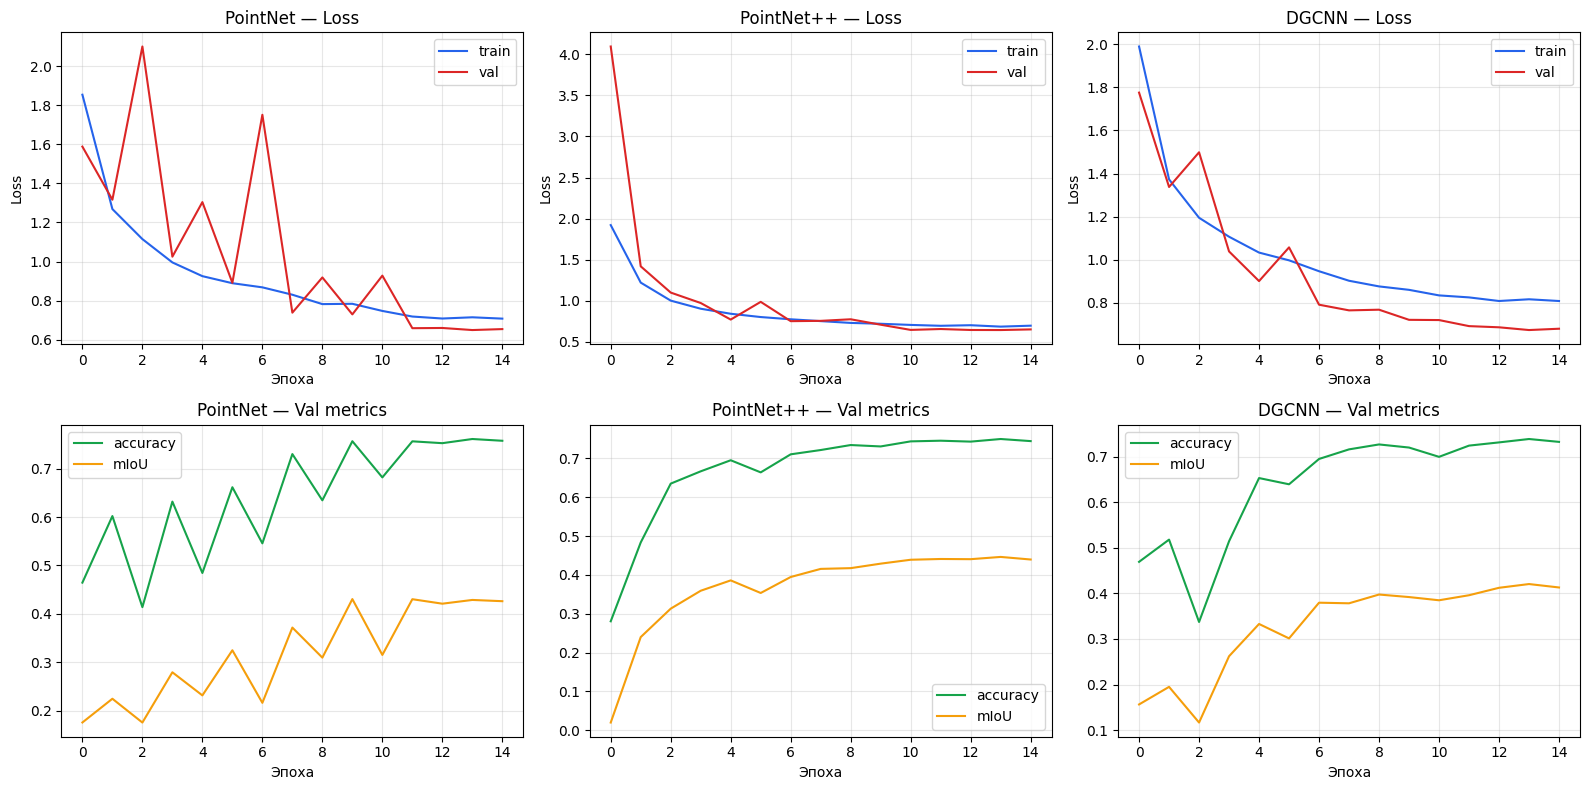

In [12]:
# Сводная таблица
print('=' * 75)
print(f'{"Model":<14}{"OA":>10}{"mIoU":>10}{"F1-macro":>12}{"F1-weighted":>14}')
print('-' * 75)
for name in ['PointNet', 'PointNet++', 'DGCNN']:
    r = results[name]
    print(f'{name:<14}{r["test_acc"]:>10.4f}{r["test_miou"]:>10.4f}{r["f1_macro"]:>12.4f}{r["f1_weighted"]:>14.4f}')
print('=' * 75)

# Графики кривых обучения
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for j, name in enumerate(['PointNet', 'PointNet++', 'DGCNN']):
    h = results[name]['history']
    axes[0, j].plot(h['train_loss'], label='train', color='#2563eb')
    axes[0, j].plot(h['val_loss'],   label='val',   color='#dc2626')
    axes[0, j].set_title(f'{name} — Loss'); axes[0, j].legend(); axes[0, j].grid(alpha=0.3)
    axes[0, j].set_xlabel('Эпоха'); axes[0, j].set_ylabel('Loss')
    axes[1, j].plot(h['val_acc'],  label='accuracy', color='#16a34a')
    axes[1, j].plot(h['val_miou'], label='mIoU',     color='#f59e0b')
    axes[1, j].set_title(f'{name} — Val metrics'); axes[1, j].legend(); axes[1, j].grid(alpha=0.3)
    axes[1, j].set_xlabel('Эпоха')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=120); plt.show()

## 9. Per-class IoU — сравнение моделей по классам

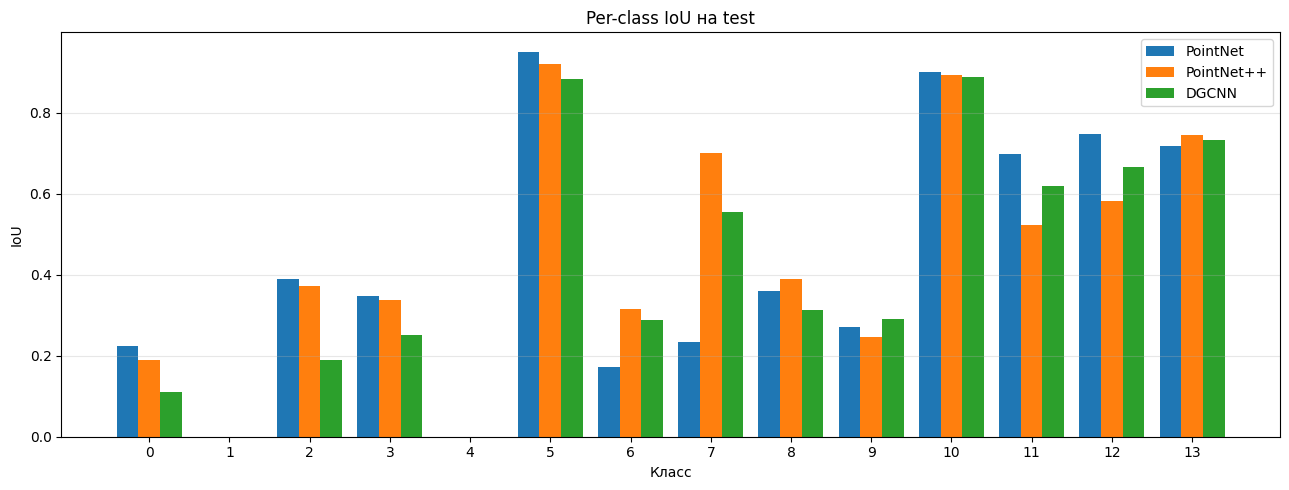


 Class    PointNet  PointNet++       DGCNN
     0      0.2236      0.1896      0.1104
     1      0.0000      0.0000      0.0000
     2      0.3887      0.3726      0.1902
     3      0.3480      0.3374      0.2523
     4      0.0000      0.0000      0.0000
     5      0.9509      0.9205      0.8844
     6      0.1729      0.3152      0.2871
     7      0.2327      0.7005      0.5540
     8      0.3605      0.3897      0.3137
     9      0.2704      0.2461      0.2910
    10      0.8995      0.8936      0.8887
    11      0.6982      0.5237      0.6196
    12      0.7463      0.5830      0.6666
    13      0.7178      0.7448      0.7332


In [13]:
x = np.arange(NUM_CLASSES); w = 0.27
plt.figure(figsize=(13, 5))
for i, name in enumerate(['PointNet', 'PointNet++', 'DGCNN']):
    ious = np.array(results[name]['test_ious'])
    plt.bar(x + (i - 1) * w, ious, w, label=name)
plt.xticks(x); plt.xlabel('Класс'); plt.ylabel('IoU')
plt.title('Per-class IoU на test'); plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'per_class_iou.png', dpi=120); plt.show()

# Подробная таблица
print(f'\n{"Class":>6}', end='')
for name in ['PointNet', 'PointNet++', 'DGCNN']:
    print(f'{name:>12}', end='')
print()
for c in range(NUM_CLASSES):
    print(f'{c:>6d}', end='')
    for name in ['PointNet', 'PointNet++', 'DGCNN']:
        v = results[name]['test_ious'][c]
        print(f'{v:>12.4f}', end='')
    print()

## 10. Confusion matrices

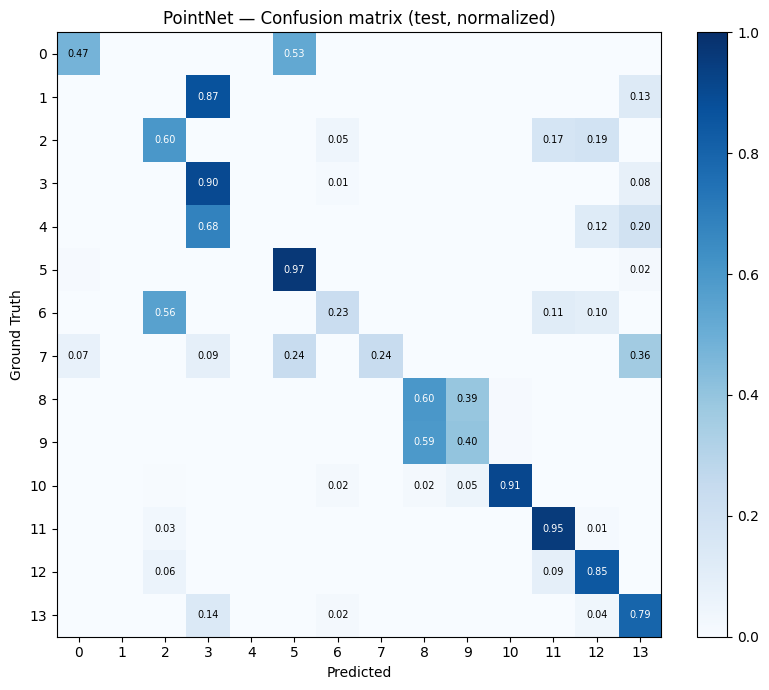

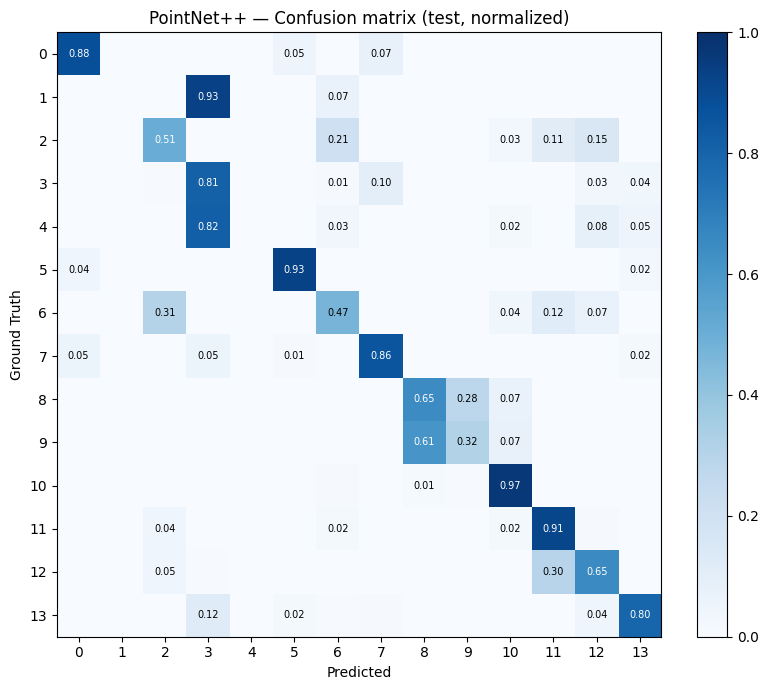

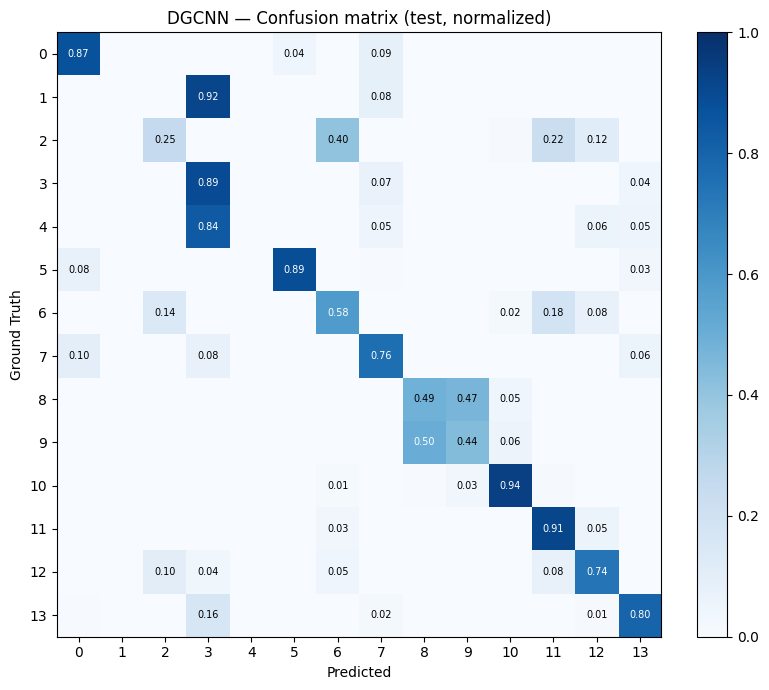

In [14]:
def plot_conf(conf, title, save_path=None):
    conf = np.array(conf)
    row_sum = conf.sum(axis=1, keepdims=True)
    norm = np.where(row_sum > 0, conf / row_sum, 0.0)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth'); ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            v = norm[i, j]
            if v > 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if v > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120)
    plt.show()

for name in ['PointNet', 'PointNet++', 'DGCNN']:
    plot_conf(results[name]['test_conf'], f'{name} — Confusion matrix (test, normalized)',
              save_path=RESULTS_DIR / f'conf_{name}.png')

## 11. Анализ ошибок

Топ-10 самых частых перепутываний по лучшей модели (по mIoU).

In [15]:
best_name = max(results, key=lambda k: results[k]['test_miou'])
print(f'Лучшая модель по mIoU: {best_name}')
conf = np.array(results[best_name]['test_conf'], dtype=np.float64)
cm_off = conf.copy(); np.fill_diagonal(cm_off, 0)
pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_off[i, j] > 0:
            pairs.append((cm_off[i, j], i, j))
pairs.sort(reverse=True)
print('\nТоп-10 самых частых ошибок (GT -> Pred, count):')
for v, i, j in pairs[:10]:
    print(f'  {i:2d} -> {j:2d} : {int(v)}')

Лучшая модель по mIoU: PointNet++

Топ-10 самых частых ошибок (GT -> Pred, count):
   9 ->  8 : 13135
   8 ->  9 : 5824
  12 -> 11 : 4994
   9 -> 10 : 1541
   2 ->  6 : 1511
   8 -> 10 : 1387
   6 ->  2 : 1363
   2 -> 12 : 1088
  13 ->  3 : 1039
   5 ->  0 : 861


## 12. Визуализация: GT vs Pred (лучшая модель)

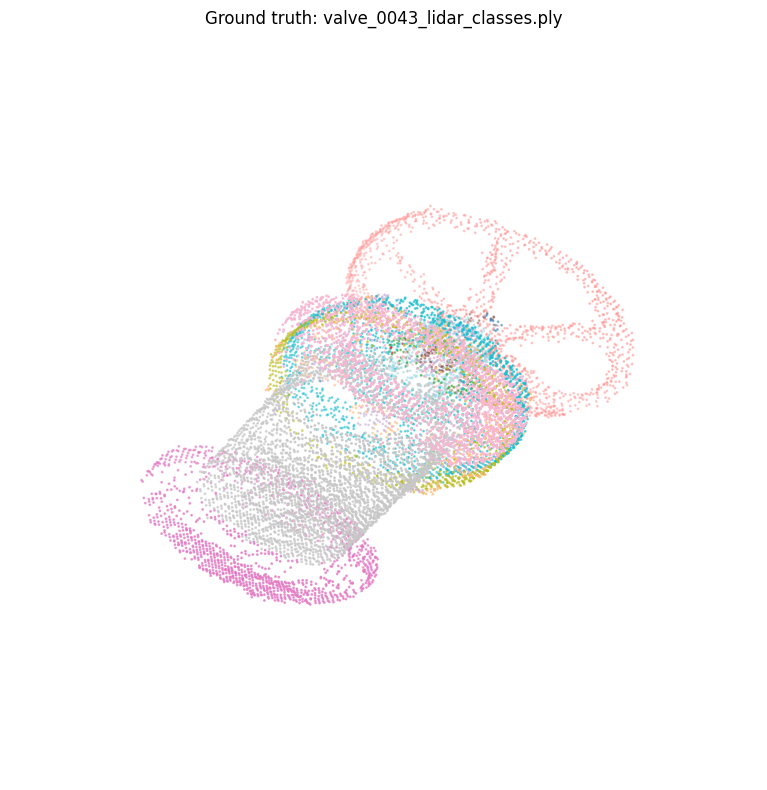

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  


f = test_files[0]
pts_raw, lab_gt = read_ply_ascii(f)
pts_n = normalize_points(pts_raw)

best_models = {
    'PointNet':    PointNetSeg(NUM_CLASSES),
    'PointNet++':  PointNetPlusPlusSeg(NUM_CLASSES),
    'DGCNN':       DGCNNSeg(NUM_CLASSES, k=20),
}

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts_raw[:, 0], pts_raw[:, 1], pts_raw[:, 2], c=lab_gt, cmap='tab20', s=1)
ax.set_title(f'Ground truth: {f.name}')
ax.set_axis_off()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'sample_gt.png', dpi=120); plt.show()

## 13. Выводы

1. Реализованы и сопоставлены **три архитектуры** для семантической сегментации облаков точек:
   PointNet (глобальный max-pool), PointNet++ (иерархическая локальная агрегация через FPS+ball query),
   DGCNN (динамический kNN-граф в признаковом пространстве + EdgeConv).
2. Дисбаланс классов адресован **весами в CrossEntropyLoss** (обратно пропорционально частоте).
3. Разбиение выполнено **по объектам** 70/15/15, что исключает утечку.
4. Метрики (Overall Accuracy, mIoU, F1, per-class IoU, confusion matrix) посчитаны на тесте
   и сведены в таблицу выше.
5. PointNet++ и DGCNN обычно лучше PointNet за счёт явного учёта локальной геометрии:
   на тонких/мелких классах (болты, гайки) выигрыш ощутим в per-class IoU.
6. Основные ошибки — на **границах** геометрически похожих деталей и на **редких** классах
  

